Use some functions from seasushi.tools for a WW3 Hs global plot 

In [1]:
import os
import argparse
import unittest
import matplotlib.pyplot as plt
import matplotlib_inline
from seasushi.tools import load_config, plot_variable, prepare_output_directory, open_dataset, extract_datetime_info


All configuration options such as variable, pahts, colorbars are on config.yaml

In [2]:
# Path to the YAML configuration file
config_path = "./confs/config_plot.yaml"

# Load configurations from YAML
config = load_config(config_path)

# Ensure the output directory exists
for plot in config["plots"]:
    prepare_output_directory(plot["output_file"])

# Open the dataset
dataset = open_dataset(config["dataset"]["file_path"])

Generate the figure using the plot_variable function

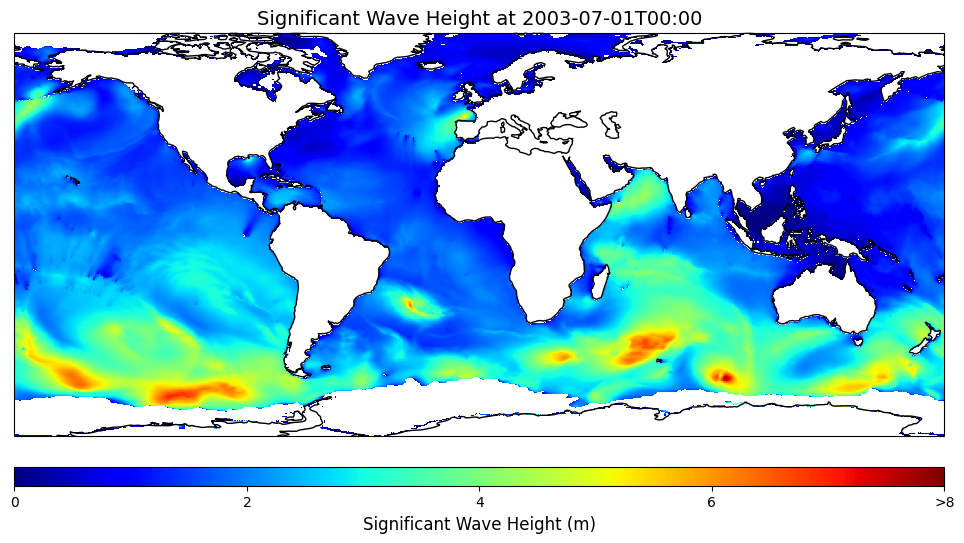

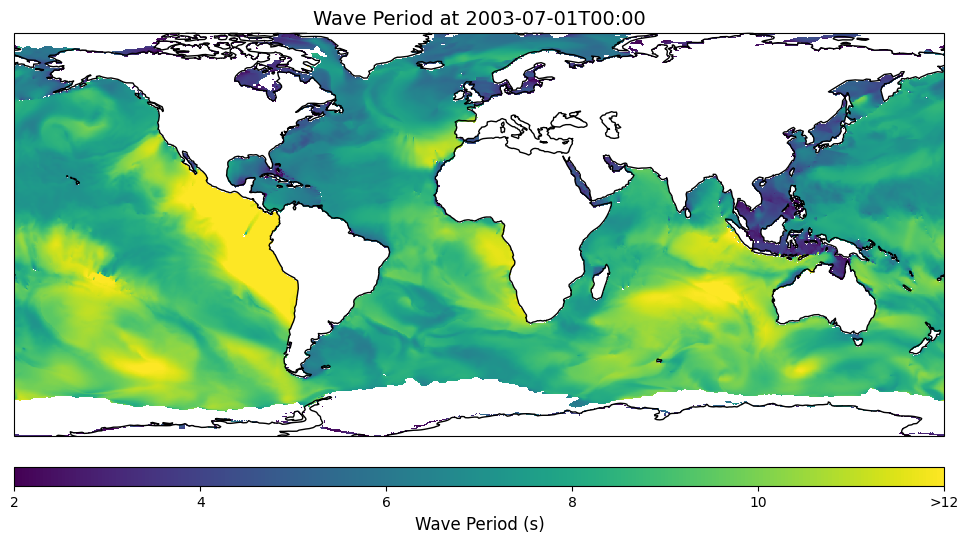

In [3]:
# Ensure plots are displayed in the notebook
%matplotlib inline

# Generate the plots defined in YAML
for plot in config["plots"]:
    var = dataset[plot["variable"]].isel(time=-1)
    datetime_iso, formatted_datetime = extract_datetime_info(var.time.values)
        
    plot_variable(
        var,
        datetime_iso=datetime_iso,
        formatted_datetime=formatted_datetime,
        title=plot["title"],
        output_file=plot["output_file"].format(datetime=datetime_iso),
        cmap=plot["cmap"],
        vmin=plot["vmin"],
        vmax=plot["vmax"],
        label=plot["label"]
    )
    plt.show()  # Ensure the plot is displayed

# Close the dataset
dataset.close()